In [1]:
# Common Python file that imports all the necessary libraries and common variables used

from setup import *

# Common link directory to save figures
out_path = "output/p1"
os.makedirs(out_path, exist_ok=True)

## Encoder Model

In [2]:
class Encoder(nn.Module):
    def __init__(self, inp_size, hidden_size):
        super(Encoder, self).__init__()

        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(inp_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden_state = self.gru(embedded, hidden_state)

        return output, hidden_state
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

## Decoder Model

In [3]:
class Decoder(nn.Module):
    def __init__(self, out_size, hidden_size):
        super(Decoder, self).__init__()

        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(out_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, out_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden_state = self.gru(embedded, hidden_state)
        output = self.softmax(self.out(output[0]))

        return output, hidden_state

## Helper Functions

In [4]:
def forward_pass(input_tensor, target_tensor, encoder, decoder, criterion):
    encoder_hidden = encoder.initHidden()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)
    loss = 0

    # Encoding
    # Encoding loop
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei].unsqueeze(0), encoder_hidden)

    # Decoding
    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    for di in range(target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        _, topi = decoder_output.topk(1)
        decoder_input = topi.squeeze().detach()

        loss += criterion(decoder_output, target_tensor[di].unsqueeze(0))

        if decoder_input.item() == EOS_token:
            break

    return loss / target_length

In [5]:
def train(input_tensor, target_tensor, encoder, decoder, encoder_optim, decoder_optim, criterion):
    encoder_optim.zero_grad()
    decoder_optim.zero_grad()

    loss = forward_pass(input_tensor, target_tensor, encoder, decoder, criterion)
    loss.backward()

    encoder_optim.step()
    decoder_optim.step()

    return loss.item()

In [6]:
# Taken from sequence2sequence.py
def eval_show_eg(encoder, decoder, n_eg=5):
    encoder.eval()
    decoder.eval()

    exact_matches = 0
    total_bleu_score = 0.0
    chencherry = SmoothingFunction()

    print(f'\n')
    print('='*70)
    print(f'Generating Validation Examples')
    print('='*70)

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()
            input_length = input_tensor.size(0)

            # Passing through encoder
            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei].unsqueeze(0), encoder_hidden)
            
            # Setting up the decoder
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden
            predicted_idx = []

            # Range is extended to account for the larger sentences
            for di in range(100):
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
                _, topi = decoder_output.topk(1)
                
                idx_pred = topi.item()
                predicted_idx.append(idx_pred)
                
                decoder_input = topi.squeeze().detach()

                if idx_pred == EOS_token:
                    break

            input_string = ''.join([idx_to_chars[index.item()] for index in input_tensor if index.item() not in (SOS_token, EOS_token)])
            target_string = ''.join([idx_to_chars[index.item()] for index in target_tensor if index.item() not in (SOS_token, EOS_token)])
            predicted_string = ''.join([idx_to_chars[index] for index in predicted_idx if index not in (SOS_token, EOS_token)])

            # Metric 1: Tradition Sequence Accuracy
            if predicted_string == target_string:
                exact_matches += 1
            
            # Metric 2: BLUE Score
            ref_tokens = [list(target_string)]
            candidate_tokens = list(predicted_string)

            bleu = sentence_bleu(ref_tokens, candidate_tokens, smoothing_function=chencherry.method1)
            total_bleu_score += bleu

            if i < n_eg:
                match_status = "PASS" if predicted_string == target_string else "FAIL"
                print(f'Input: {input_string:<12} | Target: {target_string:<12} | Predicted: {predicted_string:<12} | Match: {match_status:<4} | BLEU: {bleu:.4f}')
        
        total_samples = len(val_loader)
        final_acc = exact_matches / total_samples
        avg_bleu = total_bleu_score / total_samples

        print('='*70)
        print(f'Final Metrics across Dataset:')
        print(f'\nTraditional Exact-Match Accuracy: {final_acc * 100:.2f}% ({exact_matches} / {total_samples} samples)')
        print(f'\nAverage Validation BLEU Score: {avg_bleu:.4f}')
        print('='*70)

## Problem 1

Starting Training
Epoch 00 | Train Loss: 2.9729 | Val Loss: 2.8573
Epoch 05 | Train Loss: 2.6065 | Val Loss: 2.6721
Epoch 10 | Train Loss: 2.4235 | Val Loss: 2.6320
Epoch 15 | Train Loss: 2.3085 | Val Loss: 2.4858
Epoch 20 | Train Loss: 2.2417 | Val Loss: 2.4484
Epoch 25 | Train Loss: 2.1878 | Val Loss: 2.5453
Epoch 30 | Train Loss: 2.0757 | Val Loss: 2.5696
Epoch 35 | Train Loss: 2.0164 | Val Loss: 2.3270
Epoch 40 | Train Loss: 1.9630 | Val Loss: 2.6404
Epoch 45 | Train Loss: 1.8756 | Val Loss: 2.3151


Generating Validation Examples
Input: He replies to all customer emails immediately | Target: Il répond immédiatement à tous les e-mails des clients | Predicted: Il répordit mmmmeetmmet  mee meemee | Match: FAIL | BLEU: 0.1580
Input: We work in the office | Target: Nous travaillons au bureau | Predicted: Nous parlissns       ee  eee | Match: FAIL | BLEU: 0.1923
Input: I want a large slice of chocolate cake | Target: Je veux une grande part de gâteau au chocolat | Predicted: Je veux un 

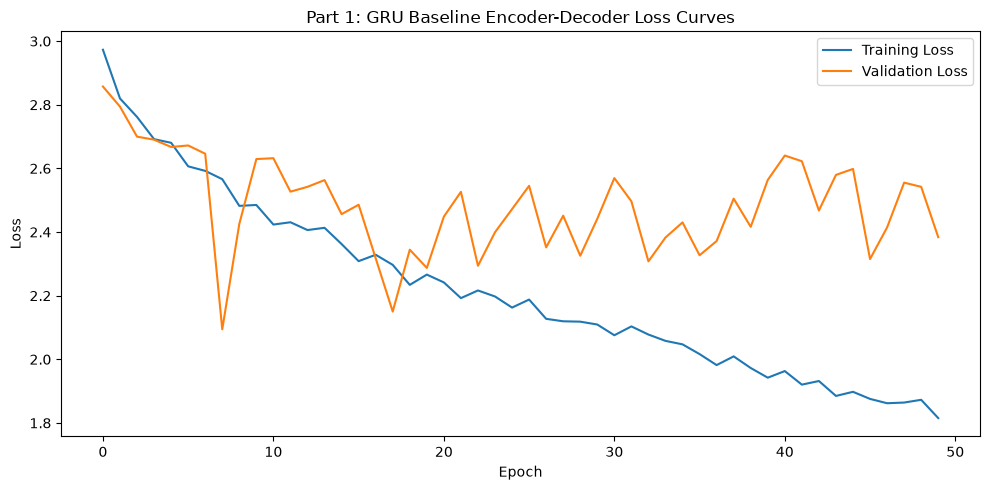

In [ ]:
encoder = Encoder(inp_size=input_size, hidden_size=hidden_size).to(device)
decoder = Decoder(hidden_size=hidden_size, out_size=output_size).to(device)

learning_rate = 0.001
encoder_optimiser = optim.Adam(encoder.parameters(), lr=learning_rate)
decoder_optimiser = optim.Adam(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()

# Initialising loss variables
train_losses = []
val_losses = []

print("="*80)
print("Starting Training")
print("="*80)

# Training and Validation Loop
for epoch in range(no_of_epochs):
    # TRAINING
    encoder.train()
    decoder.train()
    total_train_loss = 0

    for input_tensor, target_tensor in train_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = train(input_tensor, target_tensor, encoder, decoder, encoder_optimiser, decoder_optimiser, criterion)
        total_train_loss += loss
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    encoder.eval()
    decoder.eval()
    total_val_loss = 0

    with torch.no_grad():
        for input_tensor, target_tensor in val_loader:
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()
            input_length = input_tensor.size(0)
            target_length = target_tensor.size(0)
            loss = forward_pass(input_tensor, target_tensor, encoder, decoder, criterion)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

eval_show_eg(encoder, decoder, n_eg=5)
plot_loss(train_losses=train_losses, val_losses=val_losses, title="Part 1: GRU Baseline Encoder-Decoder Loss Curves", path=f'{out_path}/baseline_loss_curves')